In [206]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [207]:
digits_dataset = load_digits()
digits_dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [208]:
digits_dataset.images.shape

(1797, 8, 8)

In [209]:
digits_dataset.data.shape

(1797, 64)

In [210]:
digits_dataset.images[0].shape

(8, 8)

In [211]:
digits_dataset.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

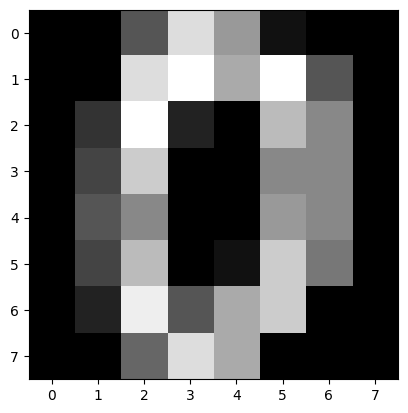

In [212]:
plt.imshow(digits_dataset.images[0], cmap="gray")

In [213]:
digits_dataset.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [214]:
x = digits_dataset.data
y = digits_dataset.target

In [215]:
digits_dataset.target[0]

np.int64(0)

In [216]:
x.shape, x.shape

((1797, 64), (1797, 64))

# Preprocesare - impartirea in date de antrenament si date de test

In [217]:
x_train, x_test, y_train, y_test =  train_test_split(x, y, test_size=0.2, random_state=419438)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1437, 64), (360, 64), (1437,), (360,))

# Antrenarea modelului

In [218]:
digits_dataset.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [219]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [220]:
knn_model = KNeighborsClassifier()
rf_model = RandomForestClassifier()
tree_model = DecisionTreeClassifier()


models = [("knn", knn_model), ("rf", rf_model), ("tree", tree_model)]


In [221]:
for name, model in models:
    model.fit(x_train, y_train)
    score = model.score(x_test, y_test)
    print("Modelul", model,  "are scorul ", score)

Modelul KNeighborsClassifier() are scorul  0.9777777777777777
Modelul RandomForestClassifier() are scorul  0.9777777777777777
Modelul DecisionTreeClassifier() are scorul  0.8583333333333333


In [222]:
from sklearn.ensemble import VotingClassifier

In [223]:
voting_model = VotingClassifier(estimators=models, weights=[0.5, 0.4, 0.1])
voting_model

,estimators,"[('knn', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,"[0.5, 0.4, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


In [224]:
voting_model.fit(x_train, y_train)

,estimators,"[('knn', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,"[0.5, 0.4, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


In [225]:
voting_model.score(x_test, y_test)

0.975

In [226]:
import pickle

In [229]:

with open("digits_model.pkl", "wb") as file_handler:
    pickle.dump(voting_model, file_handler)

In [227]:
import joblib

In [228]:
joblib.dump(voting_model, "digits_model.gz")

['digits_model.gz']

In [230]:
joblib.load("digits_model.gz")

,estimators,"[('knn', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,"[0.5, 0.4, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
